In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import scipy.stats as stats

In [3]:
data = pd.read_csv(r'F:\data analytics\DATA ANALYTICS WITH PYTHON\py.project 2\1718968258_datasets\marketing_data.csv')

In [4]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,"$66,476.00",0,1,3/7/13,99,372,...,11,4,0,0,0,0,0,0,0,US
2236,5263,1977,2n Cycle,Married,"$31,056.00",1,0,1/22/13,99,5,...,3,8,0,0,0,0,0,0,0,SP
2237,22,1976,Graduation,Divorced,"$46,310.00",1,0,12/3/12,99,185,...,5,8,0,0,0,0,0,0,0,SP
2238,528,1978,Graduation,Married,"$65,819.00",0,0,11/29/12,99,267,...,10,3,0,0,0,0,0,0,0,IND


In [5]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [7]:
data.columns
# income has extra spaces which is treated as character only , therefore we need to remove it.
# all cvariables are also starts in capital letters , therefore we need to LOWERCASE them.

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ',
       'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='object')

In [8]:
data.columns = data.columns.str.replace(' ','').str.lower()
data.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'response', 'complain', 'country'],
      dtype='object')

In [9]:
data['income'] = data['income'].str.replace('$','').str.replace(',','').astype(float)

In [10]:
data['income']

0       84835.0
1       57091.0
2       67267.0
3       32474.0
4       21474.0
         ...   
2235    66476.0
2236    31056.0
2237    46310.0
2238    65819.0
2239    94871.0
Name: income, Length: 2240, dtype: float64

In [11]:
# converting dt_customer to datetime format
data.dt_customer = pd.to_datetime(data.dt_customer)
data.dt_customer

C:\Users\Bharat Sharma\AppData\Local\Temp\ipykernel_21728\753503182.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data.dt_customer = pd.to_datetime(data.dt_customer)


0      2014-06-16
1      2014-06-15
2      2014-05-13
3      2014-05-11
4      2014-04-08
          ...    
2235   2013-03-07
2236   2013-01-22
2237   2012-12-03
2238   2012-11-29
2239   2012-09-01
Name: dt_customer, Length: 2240, dtype: datetime64[ns]

In [12]:
# MISSING VALUE IMPUTATION

In [13]:
# Checking null values:
data.isnull().sum()

id                      0
year_birth              0
education               0
marital_status          0
income                 24
kidhome                 0
teenhome                0
dt_customer             0
recency                 0
mntwines                0
mntfruits               0
mntmeatproducts         0
mntfishproducts         0
mntsweetproducts        0
mntgoldprods            0
numdealspurchases       0
numwebpurchases         0
numcatalogpurchases     0
numstorepurchases       0
numwebvisitsmonth       0
acceptedcmp3            0
acceptedcmp4            0
acceptedcmp5            0
acceptedcmp1            0
acceptedcmp2            0
response                0
complain                0
country                 0
dtype: int64

In [14]:
data.marital_status.value_counts()

marital_status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64

In [15]:
def change(x):
    if x in ['Married','Together']:
        return 'couple'
    else:
        return 'alone'
data.marital_status = data.marital_status.apply(change)

In [16]:
data.marital_status.value_counts()

marital_status
couple    1444
alone      796
Name: count, dtype: int64

In [17]:
agg_data = data.groupby(['education','marital_status'])[['income']].mean().unstack()['income']
agg_data

marital_status,alone,couple
education,,
2n Cycle,51957.984375,45597.992647
Basic,17998.350000,21663.852941
Graduation,52615.569652,52779.380952
Master,53170.472000,52785.795833
PhD,54050.657143,57343.238562


In [18]:
for edu in data.education.unique():
    for status in data.marital_status.unique():
        val = agg_data.loc[edu,status]
        data.loc[(data.education == edu) & (data.marital_status == status) & (data.income.isnull()),'income'] = val

In [19]:
data[data.income.isnull()]

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,response,complain,country


In [20]:
# create variable

data['age'] = 2025 - data['year_birth']
data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,response,complain,country,age
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,1,0,0,0,0,0,1,0,SP,55
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,5,0,0,0,0,1,1,0,CA,64
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,2,0,0,0,0,0,0,0,US,67
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,7,0,0,0,0,0,0,0,AUS,58
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,7,1,0,0,0,0,1,0,SP,36


In [21]:
data['spending'] = data.loc[:,data.columns.str.startswith('mnt')].sum(axis=1)
data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,response,complain,country,age,spending
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,0,0,0,0,1,0,SP,55,1190
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,0,0,0,0,1,1,0,CA,64,577
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,0,0,0,US,67,251
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,0,0,0,AUS,58,11
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,1,0,0,0,0,1,0,SP,36,91


In [22]:
data['childreen_count'] = data['kidhome'] + data['teenhome']
data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,response,complain,country,age,spending,childreen_count
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,0,0,0,1,0,SP,55,1190,0
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,0,0,0,1,1,0,CA,64,577,0
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,0,0,US,67,251,1
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,0,0,AUS,58,11,2
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,0,0,0,0,1,0,SP,36,91,1


In [23]:
data['has_children'] = np.where((data['kidhome'] + data['teenhome']) > 0,1,0)
data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,acceptedcmp5,acceptedcmp1,acceptedcmp2,response,complain,country,age,spending,childreen_count,has_children
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,0,0,1,0,SP,55,1190,0,0
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,0,0,1,1,0,CA,64,577,0,0
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,0,US,67,251,1,1
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,0,AUS,58,11,2,1
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,0,0,0,1,0,SP,36,91,1,1


In [24]:
data['total_purchases'] = data.loc[:,data.columns.str.endswith('purchases')].sum(axis=1)
data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,acceptedcmp1,acceptedcmp2,response,complain,country,age,spending,childreen_count,has_children,total_purchases
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,0,1,0,SP,55,1190,0,0,15
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,0,1,1,0,CA,64,577,0,0,18
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,US,67,251,1,1,11
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,AUS,58,11,2,1,4
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,0,0,1,0,SP,36,91,1,1,8


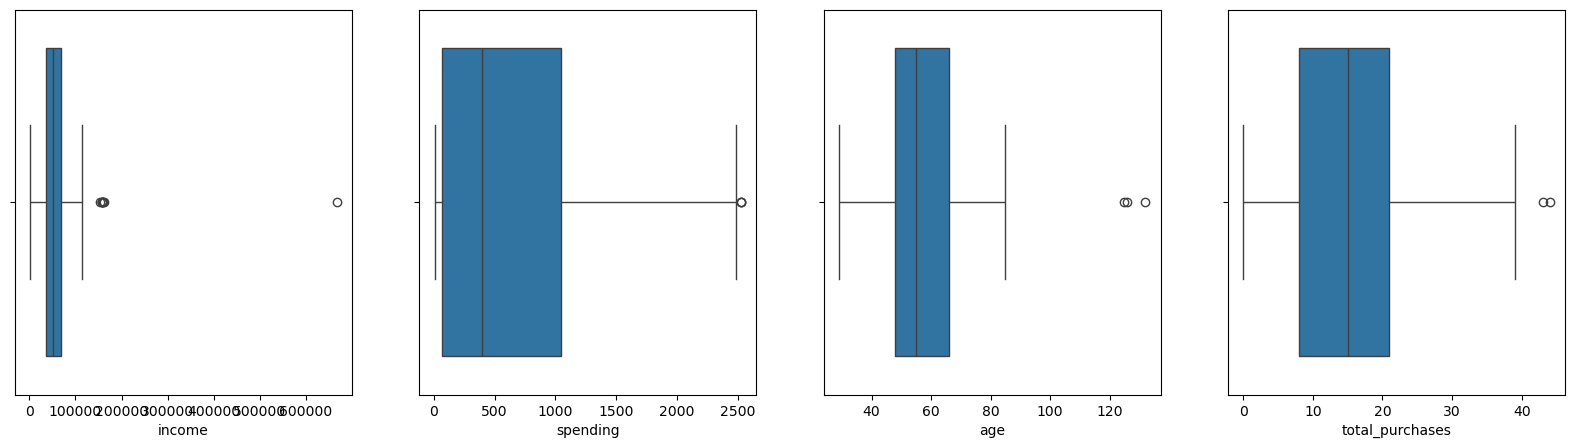

In [25]:
## BOX PLOTS $ HISTOGRAM

num_vars = ['income','spending','age','total_purchases']
f,ax = plt.subplots(1,len(num_vars),figsize=(20,5))
i = 0
for v in num_vars:
    sns.boxplot(x=data[v], ax = ax[i])
    i = i+1
plt.show()    

C:\Users\Bharat Sharma\AppData\Local\Temp\ipykernel_21728\2766656332.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[v], ax = ax[i])
C:\Users\Bharat Sharma\AppData\Local\Temp\ipykernel_21728\2766656332.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[v], ax = ax[i])
C:\Users\Bha

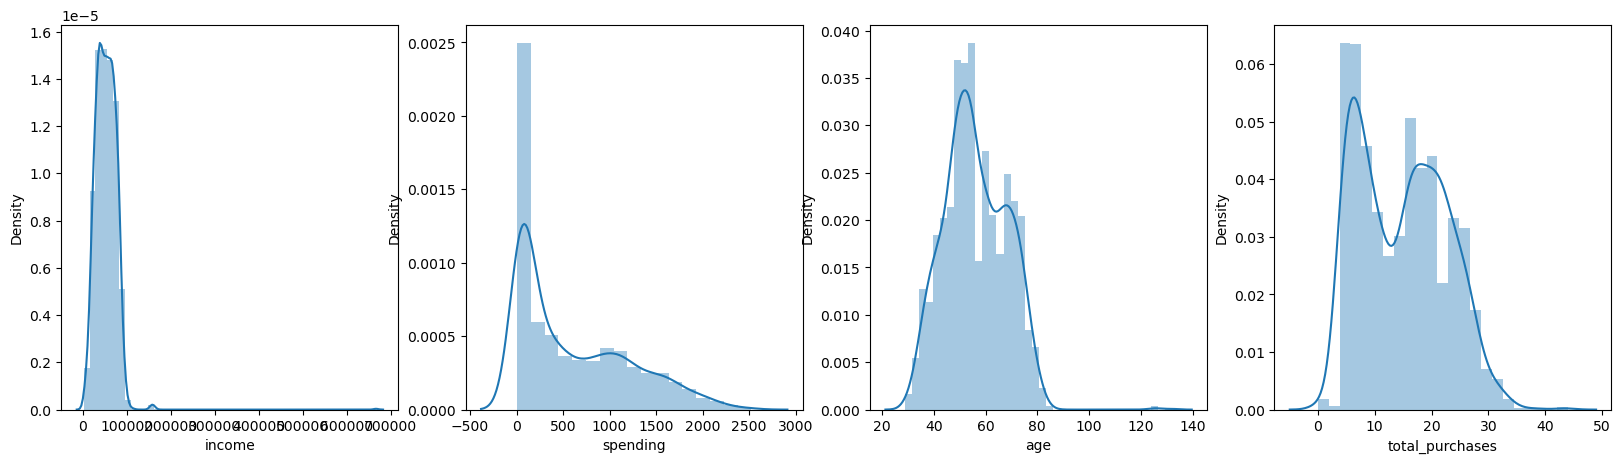

In [26]:
# HISTOGRAM
num_vars = ['income','spending','age','total_purchases']
f,ax = plt.subplots(1,len(num_vars),figsize=(20,5))
i = 0
for v in num_vars:
    sns.distplot(data[v], ax = ax[i])
    i = i+1
plt.show() 

In [27]:
# GETTING RID OF OUTLIERS.................
def outlier_detection(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3-q1
    l1 = q1 - (1.5*iqr)
    u1 = q3 + (1.5*iqr)
    return l1,u1

for v in num_vars:
    print("var = ",v)
    l1,u1 = outlier_detection(data[v])
    print('l1 = {} u1 = {}'.format(l1,u1))
    data.loc[data[v]<l1,v] = l1
    data.loc[data[v]>u1,v] = u1

var =  income
l1 = -13587.75 u1 = 117416.25
var =  spending
l1 = -1396.375 u1 = 2510.625
var =  age
l1 = 21.0 u1 = 93.0
var =  total_purchases
l1 = -11.5 u1 = 40.5


C:\Users\Bharat Sharma\AppData\Local\Temp\ipykernel_21728\3561239715.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1396.375' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data[v]<l1,v] = l1
C:\Users\Bharat Sharma\AppData\Local\Temp\ipykernel_21728\3561239715.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-11.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data[v]<l1,v] = l1


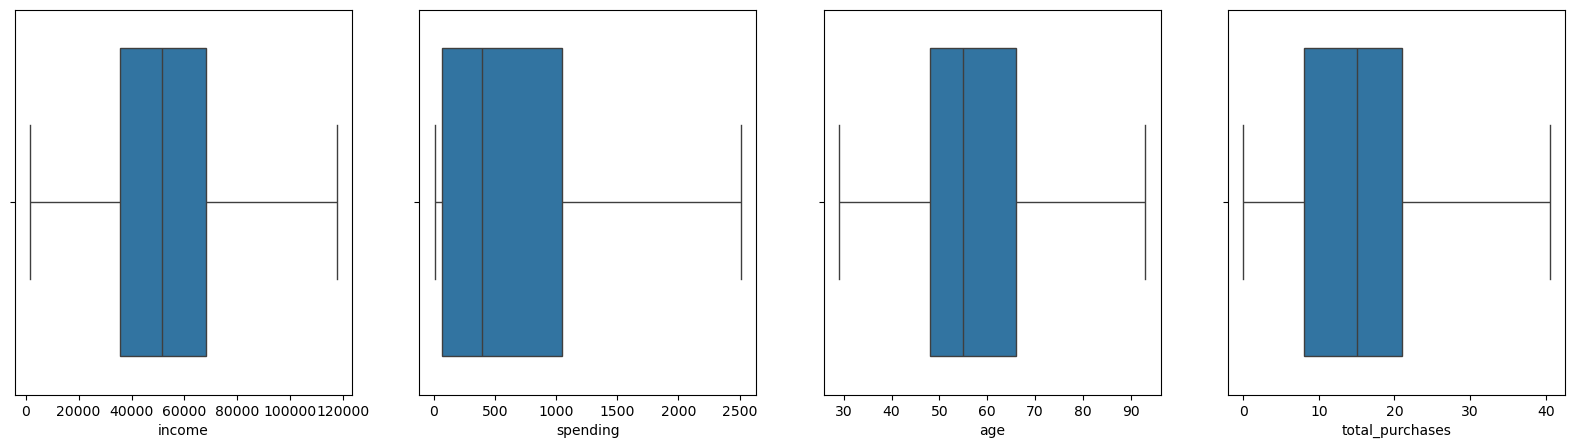

In [28]:
## NO OUTLIERS NOW .....
num_vars = ['income','spending','age','total_purchases']
f,ax = plt.subplots(1,len(num_vars),figsize=(20,5))
i = 0
for v in num_vars:
    sns.boxplot(x=data[v], ax = ax[i])
    i = i+1
plt.show() 

In [29]:
df = data.copy()
data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,acceptedcmp1,acceptedcmp2,response,complain,country,age,spending,childreen_count,has_children,total_purchases
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,0,1,0,SP,55,1190.0,0,0,15.0
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,0,1,1,0,CA,64,577.0,0,0,18.0
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,US,67,251.0,1,1,11.0
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,AUS,58,11.0,2,1,4.0
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,0,0,1,0,SP,36,91.0,1,1,8.0


In [30]:
## ENCODE DATA.....
#1. ORDINAL ENCODING
data.education.value_counts()

education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [31]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories=[['Basic','Graduation','2n Cycle','Master','PhD']])
data['edu_ordcode'] = encoder.fit_transform(data[['education']])
data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,acceptedcmp2,response,complain,country,age,spending,childreen_count,has_children,total_purchases,edu_ordcode
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,1,0,SP,55,1190.0,0,0,15.0,1.0
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,1,1,0,CA,64,577.0,0,0,18.0,1.0
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,0,US,67,251.0,1,1,11.0,1.0
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,0,0,0,AUS,58,11.0,2,1,4.0,1.0
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,0,1,0,SP,36,91.0,1,1,8.0,1.0


In [32]:
encoder = OneHotEncoder(drop = 'first', sparse_output = False)
encoded_country = encoder.fit_transform(data[['country']])
encoded_country_df = pd.DataFrame(encoded_country,columns = encoder.get_feature_names_out(['country']))
encoded_country_df

,country_CA,country_GER,country_IND,country_ME,country_SA,country_SP,country_US
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...
2235,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2236,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2237,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2238,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [33]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['id', 'year_birth', 'income', 'kidhome', 'teenhome', 'recency',
       'mntwines', 'mntfruits', 'mntmeatproducts', 'mntfishproducts',
       'mntsweetproducts', 'mntgoldprods', 'numdealspurchases',
       'numwebpurchases', 'numcatalogpurchases', 'numstorepurchases',
       'numwebvisitsmonth', 'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5',
       'acceptedcmp1', 'acceptedcmp2', 'response', 'complain', 'age',
       'spending', 'childreen_count', 'has_children', 'total_purchases',
       'edu_ordcode'],
      dtype='object')

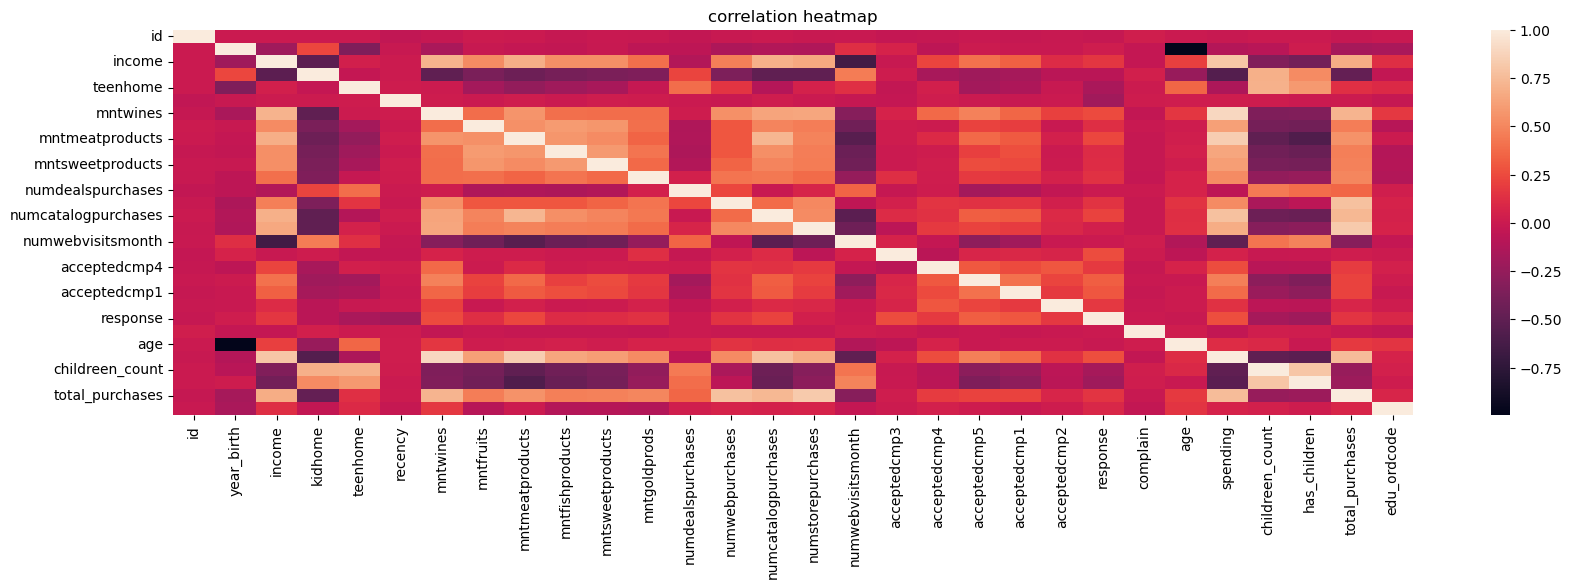

In [34]:
corr_matrix = data[num_cols].corr()
plt.figure(figsize = (20,5))
sns.heatmap(corr_matrix, annot= False)
plt.title('correlation heatmap')
plt.show()

In [35]:
## HYPOTHESES TESTING....


#  HO: Null hypothesis: For old customers the number of purchases in store is less or equal to number of purchases online
#  H1: Alternate: For old customers the number of purchases in store is GREATER than number of purchases online

store = data.loc[data.age>=60,'numstorepurchases']
web = data.loc[data.age>=60,'numwebpurchases']
stats.ttest_ind(store,web,alternative='greater')


TtestResult(statistic=np.float64(12.739120193794443), pvalue=np.float64(6.908596720806311e-36), df=np.float64(1718.0))

In [36]:
# the p value is very low than alpha - 5% (0.005), we shall reject the Null Hypothesis.... 
# we conclude that old customers the number of purchases in store is GREATER than number of purchases online.

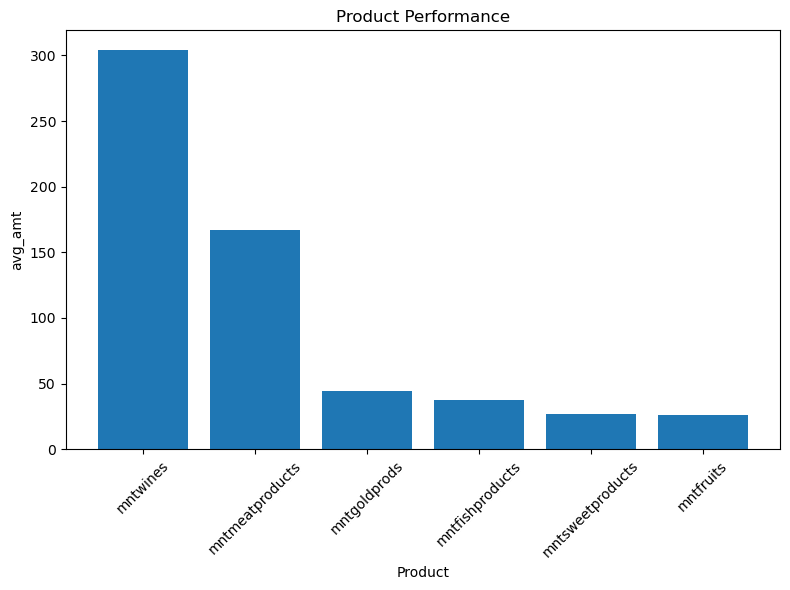

In [43]:
## VISUALISATION...............
#1: Visualize the performance of products (prod_data) using a bar plot\n",

prod_data = data.loc[:,data.columns.str.startswith('mnt')].mean().round(2).sort_values(ascending = False)
plt.figure(figsize=(8, 6))
plt.bar(prod_data.index, prod_data.values)
plt.xlabel('Product')
plt.ylabel('avg_amt')
plt.title('Product Performance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

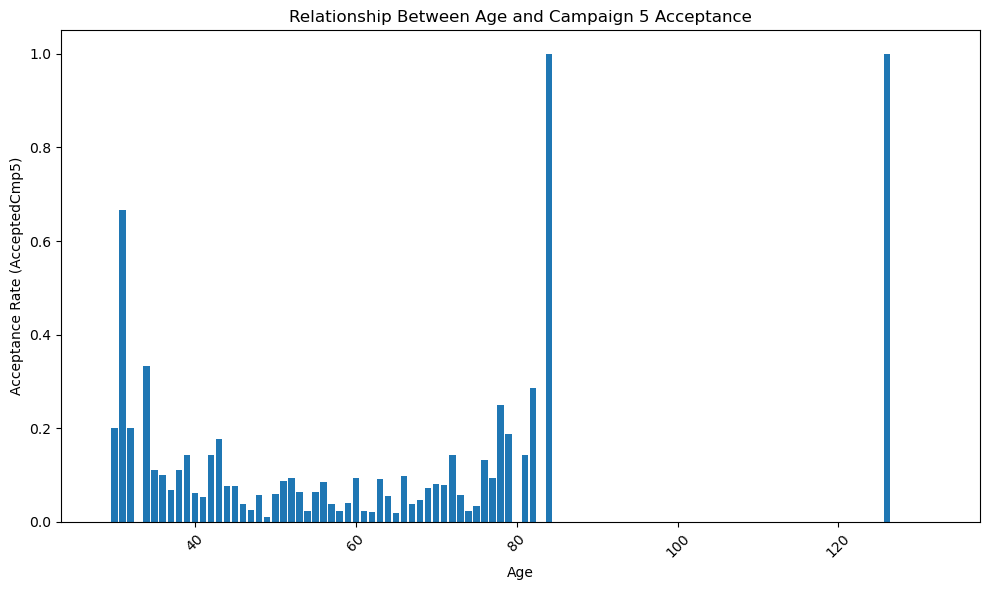

In [46]:
# Explore the relationship between age and campaign acceptance rate (acceptedcmp5) using a bar plot
data['age'] = 2025 - data['year_birth']
age_accept = (data.groupby('age')['acceptedcmp5'].mean().round(3))
plt.figure(figsize=(10, 6))
plt.bar(age_accept.index, age_accept.values)

plt.xlabel('Age')
plt.ylabel('Acceptance Rate (AcceptedCmp5)')
plt.title('Relationship Between Age and Campaign 5 Acceptance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

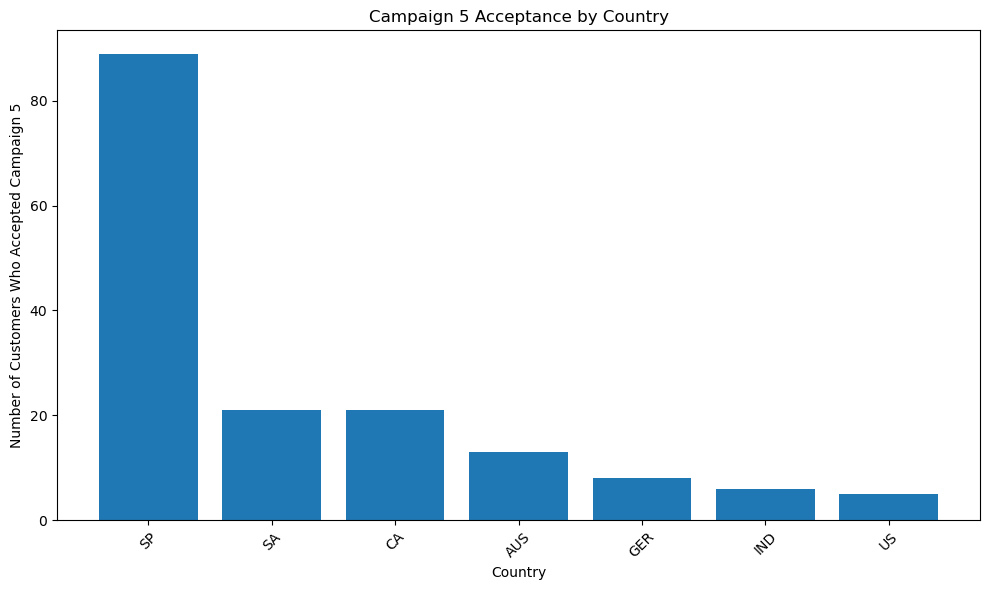

In [47]:
# Determine the country with the most customers who accepted the last campaign using a bar plot
country_accept = (
    data[data['acceptedcmp5'] == 1]        # filter accepted customers
        .groupby('country')
        .size()
        .sort_values(ascending=False)
)
plt.figure(figsize=(10, 6))
plt.bar(country_accept.index, country_accept.values)

plt.xlabel('Country')
plt.ylabel('Number of Customers Who Accepted Campaign 5')
plt.title('Campaign 5 Acceptance by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

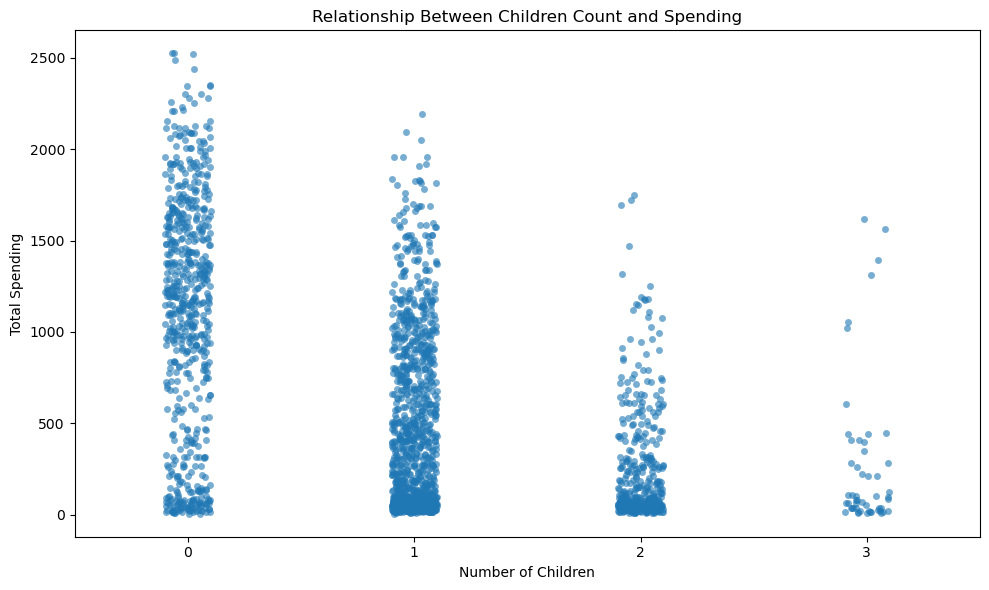

In [49]:
## Analyze the relationship between children_count and spending using a strip plot
data['children_count'] = data['kidhome'] + data['teenhome']

# Create spending variable
mnt_cols = ['mntwines','mntfruits','mntmeatproducts','mntfishproducts',
            'mntsweetproducts','mntgoldprods']
data['spending'] = data[mnt_cols].sum(axis=1)

# Strip plot
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=data,
    x='children_count',
    y='spending',
    jitter=True,
    alpha=0.6
)

plt.xlabel('Number of Children')
plt.ylabel('Total Spending')
plt.title('Relationship Between Children Count and Spending')
plt.tight_layout()
plt.show()

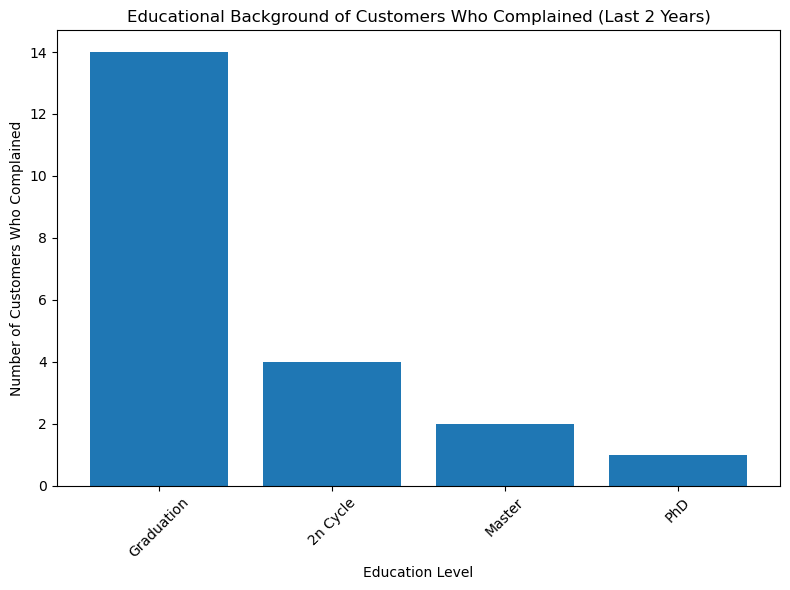

In [50]:
## Visualize the educational background of customers who complained in the last two years using a bar plot
# Filter customers who complained
complained_data = data[data['complain'] == 1]

# Count education levels among complainers
edu_counts = complained_data['education'].value_counts()

# Plot
plt.figure(figsize=(8, 6))
plt.bar(edu_counts.index, edu_counts.values)

plt.xlabel('Education Level')
plt.ylabel('Number of Customers Who Complained')
plt.title('Educational Background of Customers Who Complained (Last 2 Years)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

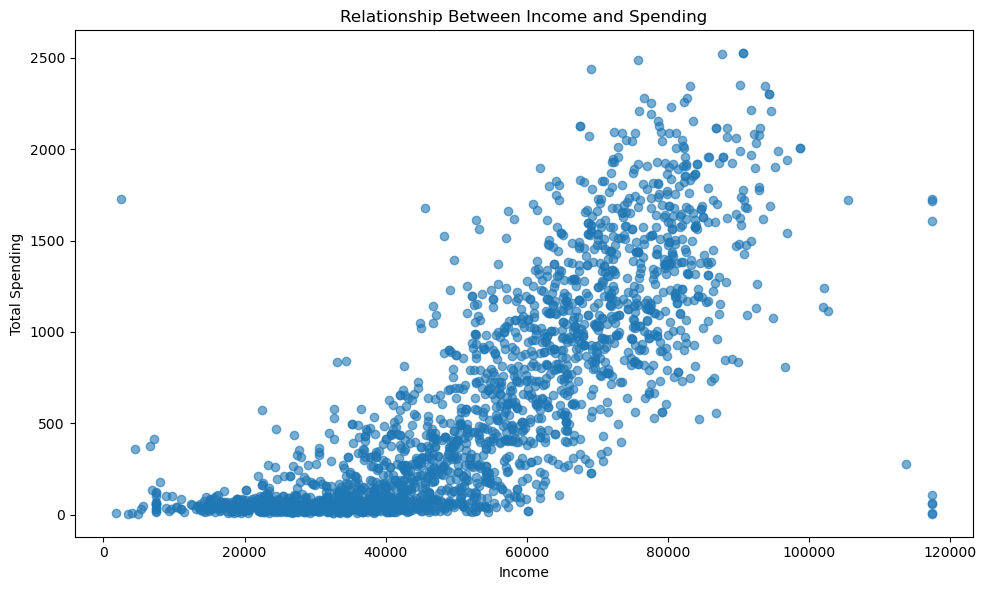

In [51]:
# Explore the relationship between income and spending using a scatter plot
# Fix column name (it contains spaces)
data['Income'] = data['income']
# Create spending variable
mnt_cols = ['mntwines','mntfruits','mntmeatproducts','mntfishproducts',
            'mntsweetproducts','mntgoldprods']
data['spending'] = data[mnt_cols].sum(axis=1)
# Scatter plot (income vs spending)
plt.figure(figsize=(10, 6))
plt.scatter(data['income'], data['spending'], alpha=0.6)

plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.title('Relationship Between Income and Spending')
plt.tight_layout()
plt.show()
